# 本地摄像头实时预测

同济子豪兄 2023-7-13 8-19

本地测试环境：Macbook Pro

## 进入mmsegmentation目录

In [1]:
# import os
# os.chdir('mmsegmentation')

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_demo/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_demo\mmsegmentation-main


## 摄像头预测-命令行

In [10]:
!python3 demo/video_demo.py \
         0 \
         Zihao-Configs/ZihaoDataset_FastSCNN_20230818.py \
         checkpoint/Zihao_FastSCNN.pth \
         --device cpu \
         --opacity 0.5 \
         --show

## 摄像头预测-OpenCV

### 导入工具包

In [2]:
import time
import numpy as np
import cv2

import matplotlib.pyplot as plt
%matplotlib inline

import mmcv
from mmseg.apis import init_model, inference_model

### 载入训练好的模型

In [3]:
# 模型 config 配置文件
config_file = 'Zihao-Configs/ZihaoDataset_PSPNet_20230818.py'

# 模型 checkpoint 权重文件
checkpoint_file = 'work_dirs/ZihaoDataset-PSPNet/best_mIoU_iter_1000.pth'

# device = 'cpu'
device = 'cuda:0'

In [4]:
model = init_model(config_file, checkpoint_file, device=device)

Loads checkpoint by local backend from path: work_dirs/ZihaoDataset-PSPNet/best_mIoU_iter_1000.pth


E:\bishe_demo\mmsegmentation-main\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


### 各类别的配色方案（BGR）

In [5]:
# palette = [
#     ['background', [127,127,127]],
#     ['red', [0,0,200]],
#     ['green', [0,200,0]],
#     ['white', [144,238,144]],
#     ['seed-black', [30,30,30]],
#     ['seed-white', [8,189,251]]
# ]


# 自定义 Cityscapes 19 个类别的配色方案（BGR 格式）
palette = [
    ['road', [100, 100, 100]],  # 道路
    ['sidewalk', [200, 50, 200]],  # 人行道
    ['building', [50, 50, 50]],  # 建筑
    ['wall', [150, 150, 200]],  # 墙
    ['fence', [200, 150, 150]],  # 栅栏
    ['pole', [150, 150, 150]],  # 杆子
    ['traffic light', [255, 200, 0]],  # 交通灯
    ['traffic sign', [255, 255, 0]],  # 交通标志
    ['vegetation', [0, 200, 0]],  # 植被
    ['terrain', [200, 255, 200]],  # 地形
    ['sky', [0, 150, 255]],  # 天空
    ['person', [255, 0, 0]],  # 人
    ['rider', [255, 100, 0]],  # 骑行者
    ['car', [0, 0, 255]],  # 汽车
    ['truck', [0, 0, 150]],  # 卡车
    ['bus', [0, 100, 150]],  # 公交车
    ['train', [0, 150, 150]],  # 火车
    ['motorcycle', [0, 0, 200]],  # 摩托车
    ['bicycle', [200, 0, 100]]  # 自行车
]

palette_dict = {}
for idx, each in enumerate(palette):
    palette_dict[idx] = each[1]

In [6]:
palette_dict

{0: [100, 100, 100],
 1: [200, 50, 200],
 2: [50, 50, 50],
 3: [150, 150, 200],
 4: [200, 150, 150],
 5: [150, 150, 150],
 6: [255, 200, 0],
 7: [255, 255, 0],
 8: [0, 200, 0],
 9: [200, 255, 200],
 10: [0, 150, 255],
 11: [255, 0, 0],
 12: [255, 100, 0],
 13: [0, 0, 255],
 14: [0, 0, 150],
 15: [0, 100, 150],
 16: [0, 150, 150],
 17: [0, 0, 200],
 18: [200, 0, 100]}

### 逐帧处理函数

In [7]:
opacity = 0.4 # 透明度，越大越接近原图

In [8]:
def process_frame(img_bgr):
    
    # 记录该帧开始处理的时间
    start_time = time.time()
    
    # 语义分割预测
    result = inference_model(model, img_bgr)
    pred_mask = result.pred_sem_seg.data[0].cpu().numpy()
    
    # 将预测的整数ID，映射为对应类别的颜色
    pred_mask_bgr = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3))
    for idx in palette_dict.keys():
        pred_mask_bgr[np.where(pred_mask==idx)] = palette_dict[idx]
    pred_mask_bgr = pred_mask_bgr.astype('uint8')
    
    # 将语义分割预测图和原图叠加显示
    pred_viz = cv2.addWeighted(img_bgr, opacity, pred_mask_bgr, 1-opacity, 0)
    
    # 记录该帧处理完毕的时间
    end_time = time.time()
    # 计算每秒处理图像帧数FPS
    FPS = 1/(end_time - start_time)

    # 在画面上写字：图片，字符串，左上角坐标，字体，字体大小，颜色，字体粗细
    scaler = 1 # 文字大小
    FPS_string = 'FPS {:.2f}'.format(FPS) # 写在画面上的字符串
    img_bgr = cv2.putText(pred_viz, FPS_string, (25 * scaler, 100 * scaler), cv2.FONT_HERSHEY_SIMPLEX, 1.25 * scaler, (255, 0, 255), 2 * scaler)
    
    return img_bgr

### 调用摄像头拍摄一帧画面

In [9]:
# 获取摄像头，0为电脑默认摄像头，1为外接摄像头
cap = cv2.VideoCapture(0)

time.sleep(1) # 等一秒，拍照
# 从摄像头捕获一帧画面
success, frame = cap.read()

cap.release() # 关闭摄像头
cv2.destroyAllWindows() # 关闭图像窗口

In [10]:
frame.shape

(480, 640, 3)

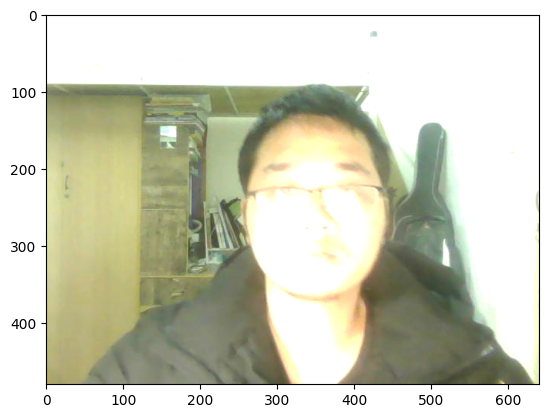

In [11]:
plt.imshow(frame[:,:,::-1])
plt.show()

In [ ]:
frame = process_frame(frame)

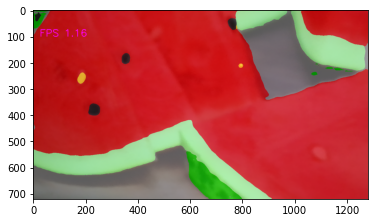

In [26]:
plt.imshow(frame[:,:,::-1])
plt.show()

### 摄像头实时画面逐帧处理

In [9]:
# 调用摄像头逐帧实时处理模板
# 不需修改任何代码，只需修改process_frame函数即可
# 同济子豪兄 2021-7-8

# 导入opencv-python
import cv2
import time

# 获取摄像头，传入0表示获取系统默认摄像头
cap = cv2.VideoCapture(1)

# 打开cap
cap.open(0)

# 无限循环，直到break被触发
while cap.isOpened():
    
    # 获取画面
    success, frame = cap.read()
    
    if not success: # 如果获取画面不成功，则退出
        print('获取画面不成功，退出')
        break
    
    ## 逐帧处理
    frame = process_frame(frame)
    
    # 展示处理后的三通道图像
    cv2.imshow('my_window',frame)
    
    key_pressed = cv2.waitKey(60) # 每隔多少毫秒毫秒，获取键盘哪个键被按下
    # print('键盘上被按下的键：', key_pressed)

    if key_pressed in [ord('q'),27]: # 按键盘上的q或esc退出（在英文输入法下）
        break
    
# 关闭摄像头
cap.release()

# 关闭图像窗口
cv2.destroyAllWindows()

## 扩展阅读

Fast-SCNN论文：https://arxiv.org/abs/1902.04502

MMSegmentation模型库中的Fast-SCNN：https://github.com/open-mmlab/mmsegmentation/tree/main/configs/fastscnn

## 思考题

对比GPU和CPU，它们的速度、精度、预测结果有何不同？

对比原生pytorch的.pth模型文件预测，和后续模型部署预测，它们的速度、精度、预测结果有何不同？

对比不同语义分割模型，它们的速度、精度、预测结果有何不同？

摄像头实时画面处理时，处理一帧画面需要用时多久？时间都消耗在哪个部分？

如何进一步提升实时预测速度？